In [1]:
import math
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

### Loading data

In [2]:
# Selecting the brain region
select_region = "Isocortex-1"

In [3]:
# Loading AnnData object
group_by = "class"
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
expr_path = base_path / f"processed/WMB-10Xv3-{select_region}-raw-wmeta-filtered-DEG-{group_by}.h5ad"
adata = sc.read_h5ad(expr_path)
adata

AnnData object with n_obs × n_vars = 227325 × 2000
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'rank_genes_groups'

In [4]:
# Loading the DEG dataframe
deg_path = base_path / "outputs/DEG/" / f"WMB-10Xv3-{select_region}-DEG-{group_by}.csv"
deg_results = pd.read_csv(deg_path)
deg_results.head(5)

,01 IT-ET Glut,02 NP-CT-L6b Glut,05 OB-IMN GABA,06 CTX-CGE GABA,07 CTX-MGE GABA,08 CNU-MGE GABA,30 Astro-Epen,31 OPC-Oligo,33 Vascular,34 Immune
0,C1ql3,Hs3st4,H3f3b,Adarb2,Kcnc2,Sox2ot,Plpp3,Olig1,Sparc,Laptm5
1,Cck,Cdh18,Zbtb20,Dlx6os1,Rab3b,Alk,Slc1a3,Qk,Utrn,Inpp5d
2,Tafa1,Foxp2,Msi2,Gad1,Slc32a1,Nkain3,Slc1a2,Gjc3,Zbtb20,Cst3
3,Bdnf,Nxph3,Sox4,Erbb4,Nxph1,Crhbp,Mt1,Sox10,Epas1,Serinc3
4,Nrgn,Rprm,Ttc28,Zfp536,Grip1,Npy,Gja1,Bcas1,Gng5,Csf1r


In [5]:
adata.uns["rank_genes_groups"]["names"][:5]

array([('C1ql3', 'Hs3st4', 'H3f3b', 'Adarb2', 'Kcnc2', 'Sox2ot', 'Plpp3', 'Olig1', 'Sparc', 'Laptm5'),
       ('Cck', 'Cdh18', 'Zbtb20', 'Dlx6os1', 'Rab3b', 'Alk', 'Slc1a3', 'Qk', 'Utrn', 'Inpp5d'),
       ('Tafa1', 'Foxp2', 'Msi2', 'Gad1', 'Slc32a1', 'Nkain3', 'Slc1a2', 'Gjc3', 'Zbtb20', 'Cst3'),
       ('Bdnf', 'Nxph3', 'Sox4', 'Erbb4', 'Nxph1', 'Crhbp', 'Mt1', 'Sox10', 'Epas1', 'Serinc3'),
       ('Nrgn', 'Rprm', 'Ttc28', 'Zfp536', 'Grip1', 'Npy', 'Gja1', 'Bcas1', 'Gng5', 'Csf1r')],
      dtype=[('01 IT-ET Glut', 'O'), ('02 NP-CT-L6b Glut', 'O'), ('05 OB-IMN GABA', 'O'), ('06 CTX-CGE GABA', 'O'), ('07 CTX-MGE GABA', 'O'), ('08 CNU-MGE GABA', 'O'), ('30 Astro-Epen', 'O'), ('31 OPC-Oligo', 'O'), ('33 Vascular', 'O'), ('34 Immune', 'O')])

## Visualization
https://scanpy.readthedocs.io/en/stable/tutorials/plotting/core.html

### Volcano plot

In [6]:
def volcano_plot_class_vs_rest(
    adata,
    target_class,
    groupby="class",
    logfc_thresh=0.5,
    fdr_thresh=0.01,
    pval_floor=1e-16,
    y_log_base=10
):

    # 1) Extract DE results for the target class
    rg   = adata.uns["rank_genes_groups"]
    genes      = rg["names"][target_class]
    logfc_vals = rg["logfoldchanges"][target_class]
    pvals_adj  = rg["pvals_adj"][target_class]

    # 2) Build a DataFrame
    df = pd.DataFrame({
        "gene":     genes,
        "logFC":    logfc_vals,
        "pval_adj": pvals_adj
    })

    # 3) Cap extremely small p-values to pval_floor
    #    (so we never attempt to take log(0) → –∞).
    df["pval_capped"] = df["pval_adj"].clip(lower=pval_floor)

    # 4) Compute –log_base(pval_capped), storing it as “neglog_b”
    #    Formula:  -log_base(x) = -[log(x)/log(base)].
    df["neglog_b"] = -np.log(df["pval_capped"]) / np.log(y_log_base)

    # 5) Identify “significant” genes by (true p < fdr_thresh) AND (|logFC| > logfc_thresh)
    is_significant = (
        (df["pval_adj"] < fdr_thresh) &
        (df["logFC"].abs() > logfc_thresh)
    )

    # 6) Start plotting
    plt.figure(figsize=(7, 5))
    plt.scatter(
        df.loc[~is_significant, "logFC"],
        df.loc[~is_significant, "neglog_b"],
        c="grey", s=10, alpha=0.7, label="Not significant"
    )
    plt.scatter(
        df.loc[is_significant, "logFC"],
        df.loc[is_significant, "neglog_b"],
        c="crimson", s=12, label="Significant"
    )

    # 7) Draw threshold lines:
    #    (a) Vertical at ±logFC_thresh
    plt.axvline(+logfc_thresh,  color="green", ls="--", lw=1)
    plt.axvline(-logfc_thresh,  color="green", ls="--", lw=1)

    #    (b) Horizontal at –log_base(fdr_thresh)
    y_threshold = -np.log(fdr_thresh) / np.log(y_log_base)
    plt.axhline(y_threshold, color="blue", ls="--", lw=1)

    # 8) Label axes & title
    plt.xlabel("Log2 Fold Change")
    plt.ylabel(f"-log₍{y_log_base}₎(Adjusted p-value)")
    plt.title(f"Volcano plot: {target_class} vs. rest")

    # 9) Annotate the threshold lines in the corners
    x_lim = plt.xlim()
    y_lim = plt.ylim()

    # Label the ±logFC lines (at bottom of plot)
    plt.text(
        +logfc_thresh, y_lim[0],
        f"LogFC={logfc_thresh}", color="green",
        ha="left", va="bottom", rotation=90
    )
    plt.text(
        -logfc_thresh, y_lim[0],
        f"LogFC={-logfc_thresh}", color="green",
        ha="right", va="bottom", rotation=90
    )

    # Label the FDR threshold (at left of plot)
    plt.text(
        x_lim[0], y_threshold,
        f"FDR={fdr_thresh}", color="blue",
        ha="left", va="bottom"
    )

    # 10) Legend and final layout
    plt.legend()
    plt.tight_layout()

    # 11) Save & display
    # plt.savefig(f"figures/volcano_plot_{target_class}.svg", dpi=300)
    plt.show()


/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


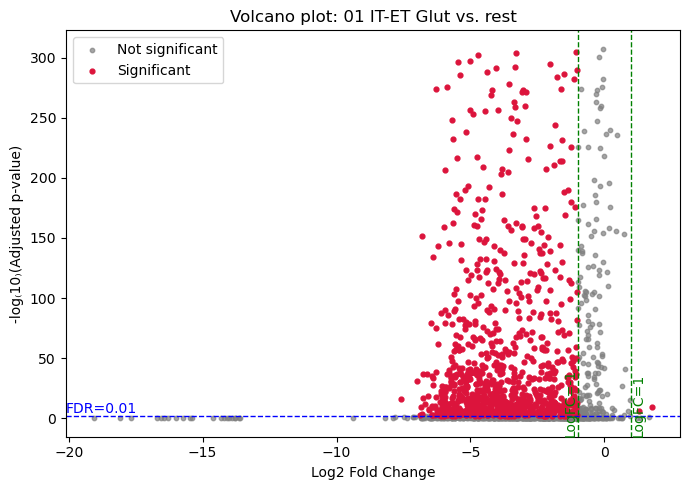

In [7]:
# Example usage:
volcano_plot_class_vs_rest(
    adata,
    target_class="01 IT-ET Glut",
    groupby=group_by,
    logfc_thresh=1,
    fdr_thresh=0.01,
    pval_floor=1e-1600,
    y_log_base=10
)

### MA Plot

In [8]:
from scipy import sparse

def ma_plot_with_custom_labels(
    adata,
    target_class,
    groupby="class",
    logfc_thresh=0.5,
    fdr_thresh=0.05,
    use_raw_if_available=True,
    pseudocount=1.0,
    label_genes=None,
    save_path=None,
    figsize=(6, 5)
):

    # 1) Extract DE results for the target class
    rg = adata.uns.get("rank_genes_groups", None)
    if rg is None:
        raise ValueError("rank_genes_groups results not found in adata.uns.")

    if target_class not in list(rg["names"].dtype.names):
        raise ValueError(f"'{target_class}' not found in rank_genes_groups names.")

    gene_names = rg["names"][target_class]           
    logfc_vals = rg["logfoldchanges"][target_class]  
    pvals_adj   = rg["pvals_adj"][target_class]       

    df = pd.DataFrame({
        "gene":   gene_names,
        "log2FC": logfc_vals,
        "p_adj":  pvals_adj
    }).set_index("gene")

    # 2) Pull expression matrix (raw or normalized)
    if use_raw_if_available and adata.raw is not None:
        expr_matrix = adata.raw.X.copy()
        var_names    = adata.raw.var_names
    else:
        expr_matrix = adata.X.copy()
        var_names    = adata.var_names

    if sparse.issparse(expr_matrix):
        expr_matrix = expr_matrix.toarray()

    expr_df = pd.DataFrame(expr_matrix, index=adata.obs_names, columns=var_names)

    # 3) Determine which cells are in target_class
    if groupby not in adata.obs.columns:
        raise ValueError(f"Column '{groupby}' not found in adata.obs.")
    is_target = adata.obs[groupby] == target_class
    if is_target.sum() == 0:
        raise ValueError(f"No cells labeled '{target_class}' in adata.obs['{groupby}'].")

    # 4) Compute log₂ expression for each gene in each cell
    if use_raw_if_available and adata.raw is not None:
        log_expr_df = np.log2(expr_df + pseudocount)
    else:
        log_expr_df = expr_df.copy()

    mean_target = log_expr_df.loc[is_target, :].mean(axis=0)
    mean_rest   = log_expr_df.loc[~is_target, :].mean(axis=0)

    # 5) Build A (average) and M (log₂FC) for genes present in DE results
    common_genes = df.index.intersection(var_names)
    if len(common_genes) == 0:
        raise ValueError("No overlap between DE genes and expression var_names.")

    A_vals = 0.5 * (mean_target.loc[common_genes] + mean_rest.loc[common_genes])
    M_vals = df.loc[common_genes, "log2FC"]
    P_vals = df.loc[common_genes, "p_adj"]

    plot_df = pd.DataFrame({
        "A":     A_vals,
        "M":     M_vals,
        "p_adj": P_vals
    })

    # 6) Identify “significant” genes
    sig_mask = (plot_df["p_adj"] < fdr_thresh) & (plot_df["M"].abs() > logfc_thresh)

    # 7) Plot the MA plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(
        plot_df.loc[~sig_mask, "A"],
        plot_df.loc[~sig_mask, "M"],
        c="lightgray", s=10, alpha=0.6, label="Not significant"
    )
    ax.scatter(
        plot_df.loc[sig_mask, "A"],
        plot_df.loc[sig_mask, "M"],
        c="crimson", s=14, label="Significant"
    )

    # 8) Draw horizontal lines at ±log₂ fold-change threshold
    ax.axhline(+logfc_thresh, color="green", ls="--", lw=1)
    ax.axhline(-logfc_thresh, color="green", ls="--", lw=1)

    # Annotate those threshold lines
    x_limits = ax.get_xlim()
    y_limits = ax.get_ylim()
    vert_offset = 0.01 * (y_limits[1] - y_limits[0])

    ax.text(
        x_limits[0],
        logfc_thresh + vert_offset,
        f"+{logfc_thresh}",
        color="green", va="bottom", ha="right"
    )
    ax.text(
        x_limits[0],
        -logfc_thresh - vert_offset,
        f"-{logfc_thresh}",
        color="green", va="top", ha="right"
    )

    ax.set_xlabel("Average expression (log₂ scale)")
    ax.set_ylabel("Log₂ Fold Change")
    ax.set_title(f"MA plot: {target_class} vs. rest")
    ax.legend(frameon=False)

    # 9) If the user provided a list of genes to label, annotate them
    if label_genes is not None:
        # Only keep those genes that actually appear in plot_df
        genes_present = [g for g in label_genes if g in plot_df.index]
        missing = [g for g in label_genes if g not in plot_df.index]
        if missing:
            print(f"Warning: these requested genes were not found in DE results and won’t be labeled: {missing}")

        for gene in genes_present:
            x0 = plot_df.loc[gene, "A"]
            y0 = plot_df.loc[gene, "M"]
            ax.text(
                x0,
                y0 + vert_offset,
                gene,
                fontsize=8,
                ha="center",
                color="darkred"
            )

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    plt.show()

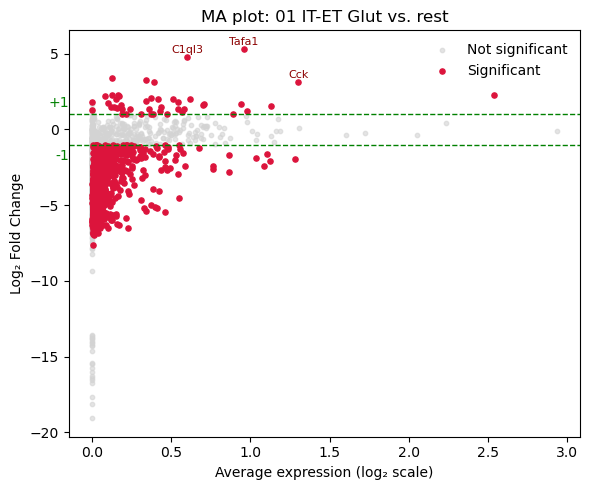

In [9]:
target_class = "01 IT-ET Glut"
ma_plot_with_custom_labels(
    adata,
    target_class=target_class,  # or whatever cluster name you used
    groupby="class",
    logfc_thresh=1,
    fdr_thresh=0.01,
    use_raw_if_available=True,    # if adata.raw has raw counts
    pseudocount=1.0,              # used only if pulling from adata.raw
    label_genes = ["C1ql3", "Cck", "Tafa1"],
    # save_path = f"figures/ma_plot_{target_class}.svg",
    figsize=(6,5)
)

### Heatmap of scaled mean expression

In [10]:
def plot_top_degs_heatmap(
    adata,
    deg_results,
    group_by="class",
    n_genes=5,
    scale=True,
    figsize=(10, 8),
    cmap="vlag",
    save_path=None
):
    """
    Plot a heatmap of mean expression of top n DEGs per class.
    Args:
        adata: AnnData object.
        deg_results: DataFrame, columns=classes, rows=ranked genes.
        group_by: str, column in adata.obs for cell classes.
        n_genes: int, number of top DEGs per class.
        scale: bool, whether to z-score scale genes across classes.
        figsize: tuple, figure size.
        cmap: str, colormap.
        save_path: str or None, path to save figure.
    """
    # 1. Get unique top genes across all classes
    top_genes = []
    for col in deg_results.columns:
        top_genes.extend(deg_results[col].dropna().head(n_genes).tolist())
    top_genes = list(dict.fromkeys(top_genes))  # preserve order, remove duplicates

    # 2. Compute mean expression per class for these genes
    class_labels = adata.obs[group_by].unique()
    class_labels = sorted(class_labels)
    expr = adata[:, top_genes].X
    if hasattr(expr, "toarray"):
        expr = expr.toarray()
    expr_df = pd.DataFrame(expr, index=adata.obs[group_by], columns=top_genes)
    mean_expr = expr_df.groupby(level=0).mean().reindex(class_labels)

    # 3. Optionally scale (z-score) genes across classes
    if scale:
        mean_expr = (mean_expr - mean_expr.mean(axis=0)) / mean_expr.std(axis=0)
        vmin, vmax = -2, 2
    else:
        vmin = vmax = None

    # 4. Plot clustered heatmap
    g = sns.clustermap(
        mean_expr.T,
        figsize=figsize,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        row_cluster=True,
        col_cluster=True,
        xticklabels=True,
        yticklabels=False,
        cbar_kws={"label": "Scaled mean expression" if scale else "Mean expression"}
    )
    g.ax_heatmap.set_xlabel("Cell class")
    
    g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(), 
    rotation=30, 
    ha='right')
    g.ax_heatmap.set_ylabel("Gene")
    
    plt.title("")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

/tmp/ipykernel_1563402/3278806509.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_expr = expr_df.groupby(level=0).mean().reindex(class_labels)


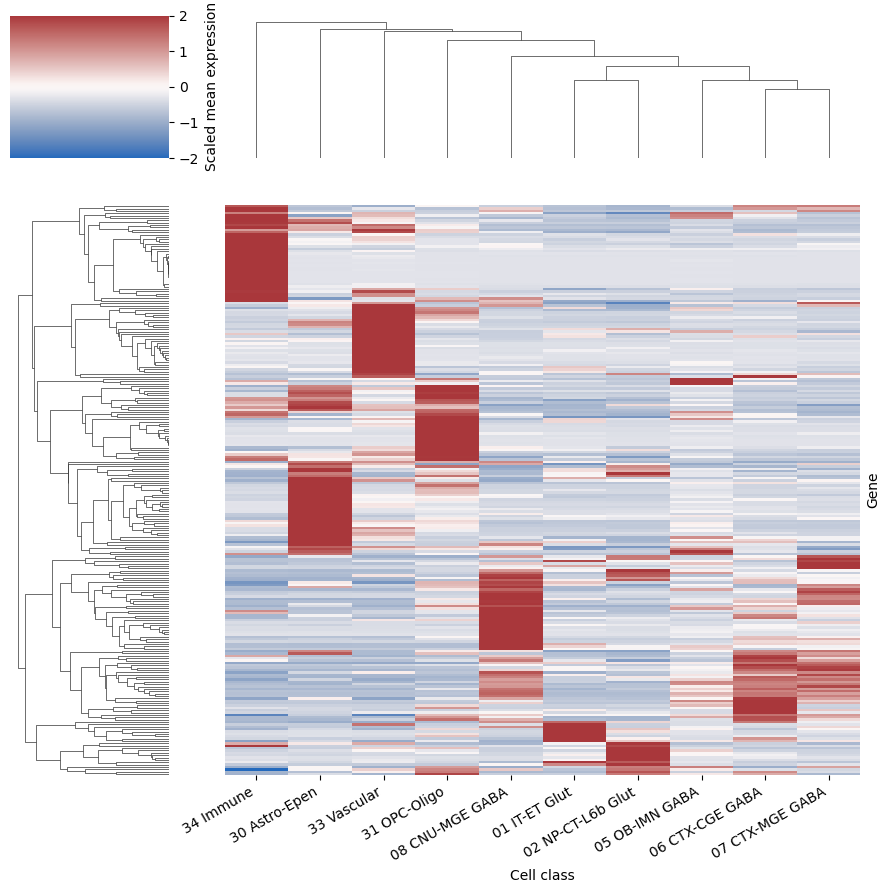

In [11]:
# Example usage:
plot_top_degs_heatmap(
    adata,
    deg_results,
    group_by=group_by,
    n_genes=30,
    scale=True,
    figsize=(9, 9),
    cmap="vlag",
    # save_path="figures/top_degs_heatmap_Isoctx.svg"
)

### Dot plot

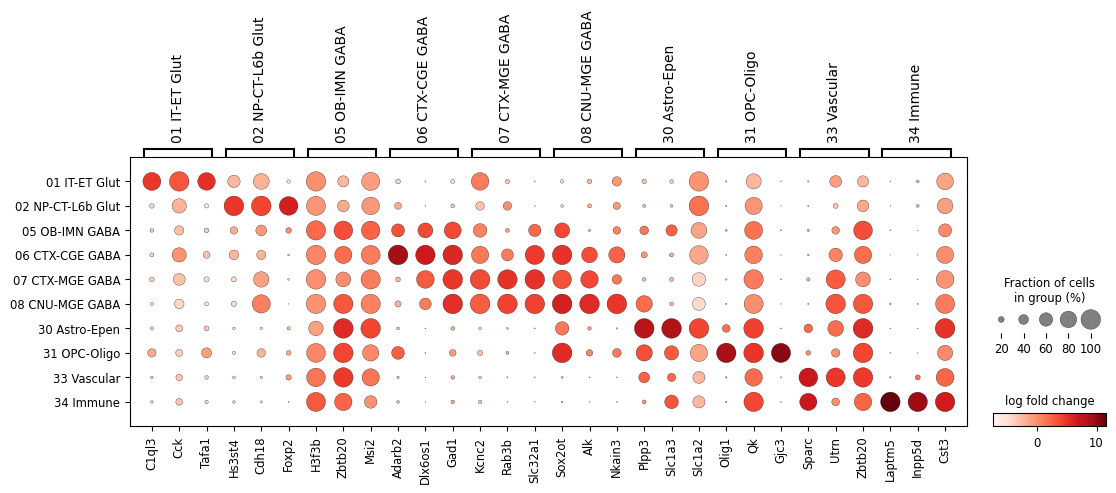

In [12]:
sc.pl.rank_genes_groups_dotplot(adata,
                                n_genes=3,
                                dendrogram=False,
                                values_to_plot="logfoldchanges",
                                # cmap = "viridis"
                                # min_logfoldchange=1,
                                # save="Isoctx.svg"
                                )

### Track plot

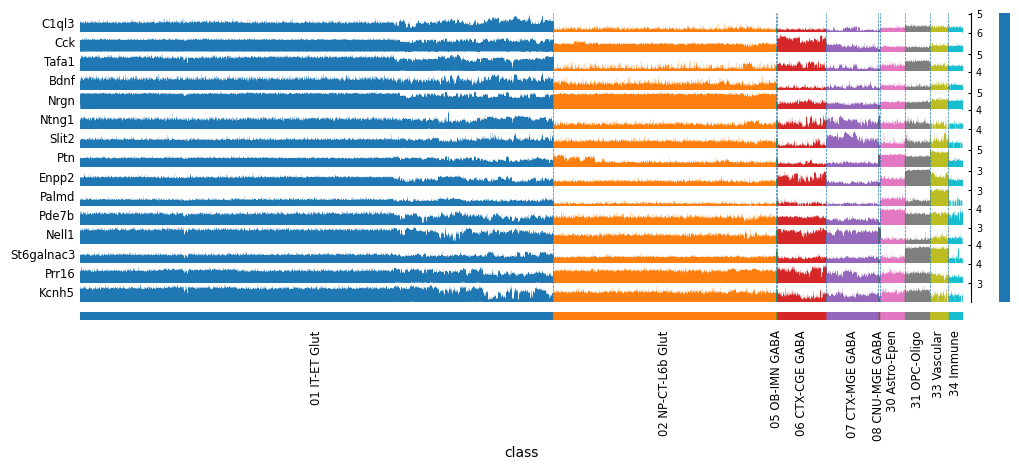

In [13]:
sc.pl.rank_genes_groups_tracksplot(adata,
                                   groups = ["01 IT-ET Glut"],
                                   n_genes=15,
                                   dendrogram=False,
                                   show = True,
                                   # save="_Isoctx.png",
                                   )

### UMAP plot

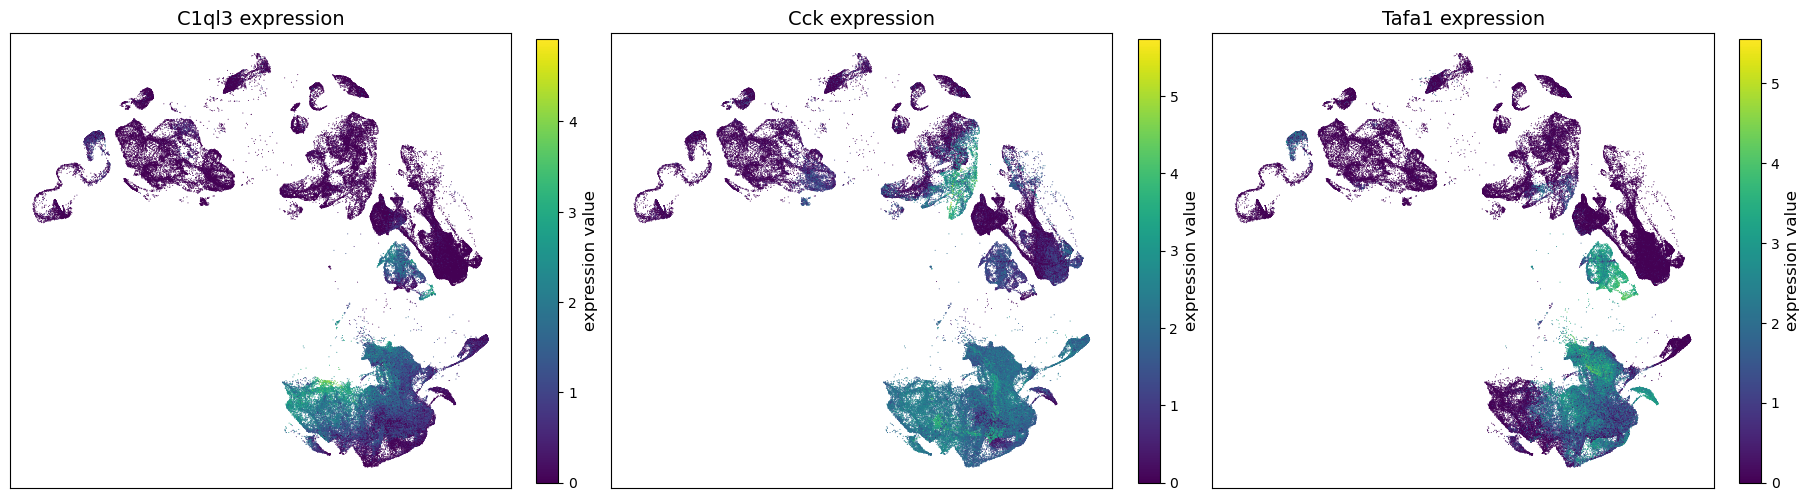

In [14]:
# Select a group and get the top genes
group = "01 IT-ET Glut"
top_genes = deg_results[group].head(3)

# Create a figure with subplots
fig, axes = plt.subplots(1, len(top_genes), figsize=(6 * len(top_genes), 6), constrained_layout=True)

# If there's only one gene, make sure axes is iterable
if len(top_genes) == 1:
    axes = [axes]

# Plot the expression of each gene using UMAP coordinates from adata.obs
for ax, gene in zip(axes, top_genes):
    scatter = ax.scatter(
        adata.obs["x"],
        adata.obs["y"],
        c=adata[:, gene].X.toarray().flatten(),
        cmap="viridis",
        s=0.5,
        edgecolor="none"
    )
    cbar = fig.colorbar(scatter, ax=ax, shrink=0.75)
    cbar.set_label("expression value", fontsize=12)  # Change font size here

    # fig.colorbar(scatter, ax=ax, shrink = 0.75, label=f"expression value")
    ax.set_title(f"{gene} expression", fontsize = 14) # , marker of \"{group}\"
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

# plt.savefig(f"figures/expression_{group}.png", dpi=300, bbox_inches='tight')
plt.show()

### Heatmap of overlaps

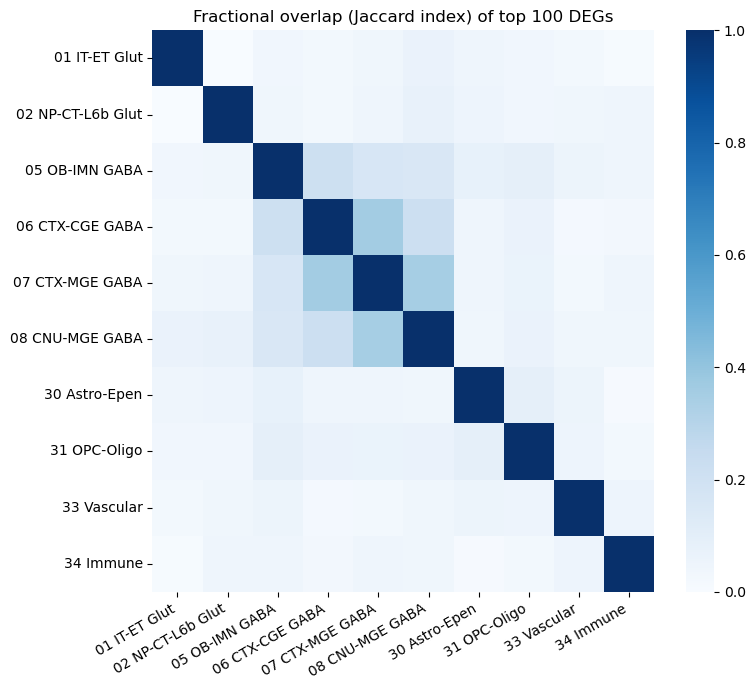

In [15]:
# Number of top DEGs to consider
top_n = 100

# Get class names and top-N gene sets
classes = deg_results.columns.tolist()
n_classes = len(classes)
deg_sets = {cls: set(deg_results[cls].dropna().head(top_n)) for cls in classes}

# Compute Jaccard index matrix
fraction_matrix = np.zeros((n_classes, n_classes), dtype=float)

for i, cls1 in enumerate(classes):
    for j, cls2 in enumerate(classes):
        set1 = deg_sets[cls1]
        set2 = deg_sets[cls2]
        union_size = len(set1 | set2)
        if union_size == 0:
            fraction_matrix[i, j] = np.nan  # avoid division by zero
        else:
            fraction_matrix[i, j] = len(set1 & set2) / union_size

# Plot heatmap
plt.figure(figsize=(8, 7))
sns.heatmap(
    fraction_matrix,
    xticklabels=classes,
    yticklabels=classes,
    cmap="Blues",
    annot=False,
    fmt=".2f",
    cbar_kws={"label": f""}
)
plt.xticks(rotation=30, ha="right")
plt.title(f"Fractional overlap (Jaccard index) of top {top_n} DEGs")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
# plt.savefig(f"figures/jaccard_index_heatmap_{select_region}.svg")
plt.show()

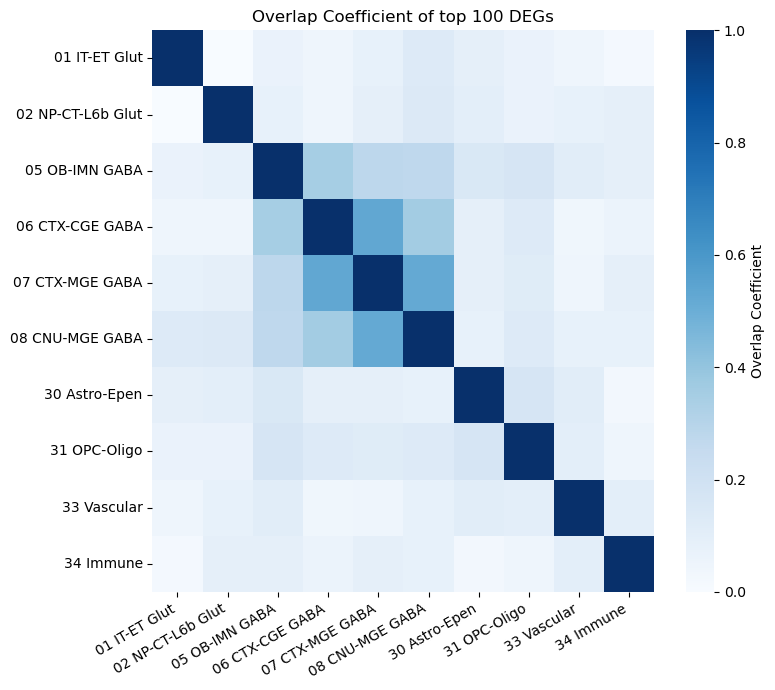

In [18]:
# Number of top DEGs to consider
top_n = 100

# Get class names and top-N gene sets
classes = deg_results.columns.tolist()
n_classes = len(classes)
deg_sets = {cls: set(deg_results[cls].dropna().head(top_n)) for cls in classes}

# Compute Overlap Coefficient matrix
fraction_matrix = np.zeros((n_classes, n_classes), dtype=float)

for i, cls1 in enumerate(classes):
    for j, cls2 in enumerate(classes):
        set1 = deg_sets[cls1]
        set2 = deg_sets[cls2]
        min_size = min(len(set1), len(set2))
        if min_size == 0:
            fraction_matrix[i, j] = np.nan  # avoid division by zero
        else:
            fraction_matrix[i, j] = len(set1 & set2) / min_size

# Plot heatmap
plt.figure(figsize=(8, 7))
sns.heatmap(
    fraction_matrix,
    xticklabels=classes,
    yticklabels=classes,
    cmap="Blues",
    annot=False,
    fmt=".2f",
    cbar_kws={"label": "Overlap Coefficient"}
)
plt.xticks(rotation=30, ha="right")
plt.title(f"Overlap Coefficient of top {top_n} DEGs")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.savefig(f"figures/overlap_coefficient_heatmap_{select_region}.svg")
plt.show()


### Bar plot of fractions

/tmp/ipykernel_795785/2981738579.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_markers, y=fractions, palette="viridis")


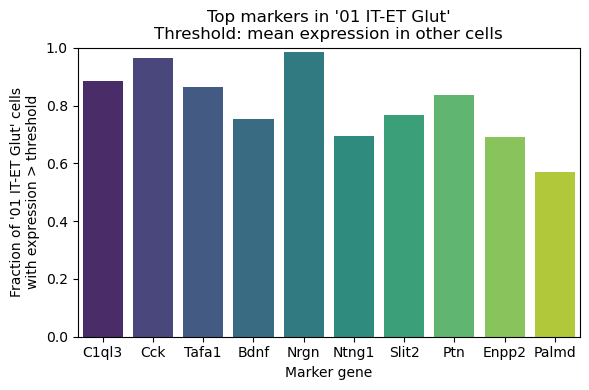

C1ql3: threshold = 0.073
Cck: threshold = 0.568
Tafa1: threshold = 0.118
Bdnf: threshold = 0.107
Nrgn: threshold = 1.826
Ntng1: threshold = 0.082
Slit2: threshold = 0.199
Ptn: threshold = 0.599
Enpp2: threshold = 0.267
Palmd: threshold = 0.066


In [64]:
# Plot: Fraction of cells in the class expressing each top marker above a threshold

# Select a group and get the top genes
target_class = "01 IT-ET Glut"
top_markers = deg_results[group].head(10)

# Option: threshold can be a fixed value or the mean expression in other cells
threshold_mode = "mean_other"  # "fixed" or "mean_other"
fixed_threshold = 0.5

# Get boolean mask for cells in the target class
class_mask = adata.obs[group_by] == target_class

fractions = []
thresholds = []
for gene in top_markers:
    expr_in_class = adata[class_mask, gene].X
    expr_other = adata[~class_mask, gene].X
    # Convert to dense if needed
    if hasattr(expr_in_class, "toarray"):
        expr_in_class = expr_in_class.toarray().flatten()
    else:
        expr_in_class = np.array(expr_in_class).flatten()
    if hasattr(expr_other, "toarray"):
        expr_other = expr_other.toarray().flatten()
    else:
        expr_other = np.array(expr_other).flatten()
    if threshold_mode == "mean_other":
        threshold = expr_other.mean()
    else:
        threshold = fixed_threshold
    frac = np.mean(expr_in_class > threshold)
    fractions.append(frac)
    thresholds.append(threshold)

# Plot
plt.figure(figsize=(6, 4))
sns.barplot(x=top_markers, y=fractions, palette="viridis")
plt.ylabel(f"Fraction of '{target_class}' cells\nwith expression > threshold")
plt.xlabel("Marker gene")
plt.ylim(0, 1)
if threshold_mode == "mean_other":
    plt.title(f"Top markers in '{target_class}'\nThreshold: mean expression in other cells")
else:
    plt.title(f"Top markers in '{target_class}'\nThreshold: {fixed_threshold}")
plt.tight_layout()
plt.savefig(f"figures/barplot_{target_class}.svg")
plt.show()

# Optionally, print thresholds used for each gene
for gene, thr in zip(top_markers, thresholds):
    print(f"{gene}: threshold = {thr:.3f}")

### Specificity (Tau score)

In [48]:
# Compute Tau scores
def compute_tau_score(adata, cluster_name, n_genes, group_by="class"):
    
    # Get expression matrix for the given cluster
    deg_expression_matrix = pd.DataFrame(
    adata.X.toarray(),  # Convert sparse matrix to dense
    index=adata.obs[group_by],  # Use the group_by column as the index
    columns=adata.var.index  # Use gene names as columns
    )

    # Select the top genes for the given cluster
    top_genes = deg_results[cluster_name].head(n_genes)

    # Compute Tau score for each gene
    tau_scores = {}
    for gene in top_genes:
        expression_values = deg_expression_matrix[gene]
        max_expression = expression_values.max()
        if max_expression > 0:
            normalized_expression = 1 - (expression_values / max_expression)
            tau_score = normalized_expression.sum() / (len(expression_values) - 1)
            tau_scores[gene] = tau_score
        else:
            tau_scores[gene] = 0

    # Convert to DataFrame
    tau_scores_df = pd.DataFrame(list(tau_scores.items()), columns=["Gene", "Tau Score"])
    return tau_scores_df

# Prompt for cluster name and number of genes
cluster_name = "01 IT-ET Glut"  # Example cluster name
n_genes = 5

# Compute Tau scores
tau_scores_df = compute_tau_score(adata, cluster_name, n_genes)
print(tau_scores_df)

    Gene  Tau Score
0  C1ql3   0.869916
1    Cck   0.764202
2  Tafa1   0.816933
3   Bdnf   0.896786
4   Nrgn   0.530414


### Marker gene correlation

In [20]:
def get_significant_degs(adata, target_class, logfc_thresh=1.0, fdr_thresh=0.05):
    """
    Return a DataFrame of DEGs for a given class passing logFC and FDR thresholds.
    Args:
        adata: AnnData object with rank_genes_groups results.
        target_class: Name of the class (must match group names in adata.uns["rank_genes_groups"]).
        logfc_thresh: Minimum absolute log2 fold change.
        fdr_thresh: Maximum adjusted p-value (FDR).
    Returns:
        DataFrame with columns: gene, logFC, pval_adj.
    """
    rg = adata.uns["rank_genes_groups"]
    genes = rg["names"][target_class]
    logfc = rg["logfoldchanges"][target_class]
    pvals_adj = rg["pvals_adj"][target_class]
    df = pd.DataFrame({
        "gene": genes,
        "logFC": logfc,
        "pval_adj": pvals_adj
    })
    sig = (df["pval_adj"] < fdr_thresh) & (abs(df["logFC"]) > logfc_thresh)
    return df[sig].reset_index(drop=True)

In [ ]:
# Example usage:
sig_degs = get_significant_degs(adata, target_class="01 IT-ET Glut", logfc_thresh=5, fdr_thresh=0.01)
print(sig_degs)

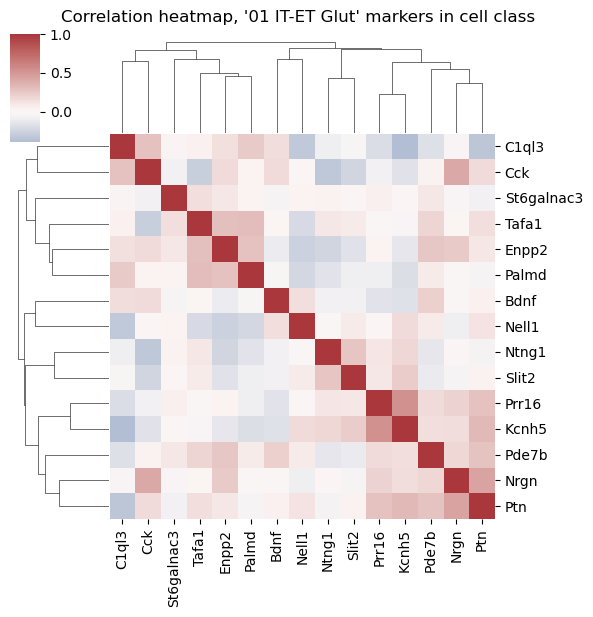

In [79]:
# Option: restrict correlation to cells of a specific class
restrict_to_class = True  # Set to True to use only cells of the target class
target_class = "01 IT-ET Glut"
all_genes = False
select_genes = deg_results[target_class].head(15)

# Extract expression matrix for significant DEGs
if all_genes:
    genes = adata.var_names.tolist()
elif select_genes is not None:
    genes = select_genes.tolist()
else:
    genes = sig_degs["gene"].tolist()


if restrict_to_class:
    cell_mask = adata.obs[group_by] == target_class
    expr_subset = adata[cell_mask, genes].X
    if hasattr(expr_subset, "toarray"):
        expr_subset = expr_subset.toarray()
    corr_matrix = np.corrcoef(expr_subset.T)
    title = f"Correlation heatmap, '{target_class}' markers in cell class"
else:
    expr = adata[:, genes].X
    if hasattr(expr, "toarray"):
        expr = expr.toarray()
    corr_matrix = np.corrcoef(expr.T)
    title = f"Correlation heatmap of \"{target_class}\" markers"

sns.clustermap(
    corr_matrix,
    row_cluster=True,
    col_cluster=True,
    xticklabels=genes,
    yticklabels=genes,
    cmap="vlag",
    center=0,
    figsize=(6, 6)
)
plt.suptitle(title, y=1.02)
plt.savefig(f"figures/heatmap_correlation_{target_class}.svg")
plt.show()

## Validation

### Biological relevance: GO enrichment analysis

In [80]:
from gprofiler import GProfiler

# Parameters
n_top_genes = 100  # Number of top DEGs to include per cluster
organism = "mmusculus"  # Mouse gene symbols (use "hsapiens" for human)

# Initialize g:Profiler client
gp = GProfiler(return_dataframe=True)

# Store all results
go_enrichment_results = []

# Loop through each cluster in the DEG results
for cluster in deg_results.columns:
    # Get the top n DEGs for the cluster
    top_genes = deg_results[cluster].dropna().head(n_top_genes).tolist()
    
    # Skip clusters with no DEGs
    if not top_genes:
        print(f"Skipping {cluster}: no DEGs found.")
        continue
    
    # Perform GO enrichment analysis
    enrichment_result = gp.profile(
        organism=organism,
        query=top_genes,
        sources=["GO:BP"]  # Biological Process, Molecular Function, Cellular Component, "GO:MF", "GO:CC"
    )
    
    # Add cluster name to the results
    enrichment_result["cluster"] = cluster
    go_enrichment_results.append(enrichment_result)

# Combine all results into a single DataFrame
go_results_df = pd.concat(go_enrichment_results, ignore_index=True)

# Display the first few rows of the results
go_results_df.head(2)

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,cluster
0,GO:BP,GO:0048731,system development,2.048048e-15,True,"""The process whose specific outcome is the pro...",4123,93,51,26963,0.548387,0.012370,query_1,"[GO:0007275, GO:0048856]",01 IT-ET Glut
1,GO:BP,GO:0007275,multicellular organism development,1.470276e-14,True,"""The biological process whose specific outcome...",4886,93,54,26963,0.580645,0.011052,query_1,"[GO:0032501, GO:0048856]",01 IT-ET Glut


In [86]:
def plot_go_dotplot(go_results_df, top_n=3, classes_on_x_axis=True, save_path=None):
    # ---------------------------------------------
    # Select top N enriched terms per cluster
    # ---------------------------------------------
    top_terms_df = (
        go_results_df
        .sort_values("p_value")
        .groupby("cluster")
        .head(top_n)
        .copy()
    )

    # Shorten term names for better plotting
    top_terms_df["term_display"] = top_terms_df["name"].str.slice(0, 50)
    top_terms_df["-log10(p)"] = -np.log10(top_terms_df["p_value"] + 1e-300)

    # Optional: sort GO terms by frequency of appearance across clusters
    term_order = (
        top_terms_df["term_display"]
        .value_counts()
        .index.tolist()
    )

    # ---------------------------------------------
    # Axes assignment based on flag
    # ---------------------------------------------
    if classes_on_x_axis:
        x, y = "cluster", "term_display"
        figsize = (8, max(5, 0.4 * len(term_order)))
        xlabel, ylabel = "", ""  # optional: customize
        xtick_rotation = 45
    else:
        x, y = "term_display", "cluster"
        figsize = (max(10, 0.4 * len(term_order)), 8)
        xlabel, ylabel = "", ""
        xtick_rotation = 90

    # ---------------------------------------------
    # Create the Dot Plot
    # ---------------------------------------------
    plt.figure(figsize=figsize)
    sns.scatterplot(
        data=top_terms_df,
        x=x,
        y=y,
        size="intersection_size",
        hue="-log10(p)",
        sizes=(30, 300),
        palette="viridis",
        edgecolor="black",
        alpha=0.8,
    )

    plt.xticks(rotation=xtick_rotation, ha="right" if classes_on_x_axis else "center")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(f"Top {top_n} enriched GO terms per cell class")

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

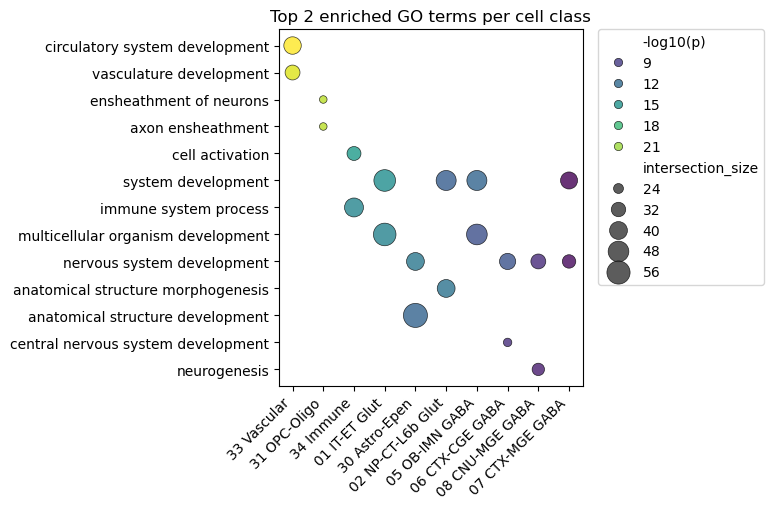

In [87]:
plot_go_dotplot(go_results_df,
                top_n=2,
                save_path="figures/go_dotplot_Isoctx.svg",
                classes_on_x_axis=True)  # cluster on y-axis